<a href="https://www.kaggle.com/code/awsaf49/hms-hbac-kerascv-starter-notebook?scriptVersionId=161271838" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<center><img src="https://keras.io/img/logo-small.png" alt="Keras logo" width="100"><br/>
This starter notebook is provided by the Keras team.</center>

# HMS - Harmful Brain Activity Classification with [KerasCV](https://github.com/keras-team/keras-cv) and [Keras](https://github.com/keras-team/keras)

> The objective of this competition is to classify seizures and other patterns of harmful brain activity in critically ill patients

This notebook guides you through the process of training and inferring a Deep Learning model, specifically EfficientNetV2, using KerasCV on the competition dataset. Specificaclly, this notebook uses spectrogram of the eeg data to classify the patterns.

Fun fact: This notebook is backend-agnostic, supporting TensorFlow, PyTorch, and JAX. Utilizing KerasCV and Keras allows us to choose our preferred backend. Explore more details on [Keras](https://keras.io/keras_core/announcement/).

In this notebook, you will learn:

* Loading the data efficiently using [`tf.data`](https://www.tensorflow.org/guide/data).
* Creating the model using KerasCV presets.
* Training the model.
* Inference and Submission on test data.

**Note**: For a more in-depth understanding of KerasCV, refer to the [KerasCV guides](https://keras.io/guides/keras_cv/).

# 🛠 | Install Libraries  

In [1]:
# !pip install -q keras_cv==0.8.2 keras==3.0.4

# 📚 | Import Libraries 

In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import sys
from pathlib import Path

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import keras_cv
import keras
from keras import ops
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print(f"Num GPUs Available: {len(gpus)}")
if len(gpus) > 0:
    print(f"GPU Model: {gpus[0]}")
    keras.mixed_precision.set_global_policy("mixed_float16")
    tf.config.optimizer.set_jit(True)

import cv2
import pandas as pd
import numpy as np
from glob import glob
from tqdm.notebook import tqdm
import joblib
import matplotlib.pyplot as plt

2026-03-11 04:39:09.006325: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-11 04:39:12.026165: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Num GPUs Available: 1
GPU Model: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


2026-03-11 04:39:18.674358: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-11 04:39:19.952935: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-11 04:39:19.956926: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

## Library Versions

In [3]:
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("KerasCV:", keras_cv.__version__)

TensorFlow: 2.16.1
Keras: 3.0.4
KerasCV: 0.8.2


# ⚙️ | Configuration

In [4]:
class CFG:
    verbose = 1  # Verbosity
    seed = 42  # Random seed
    preset = "efficientnetv2_b2_imagenet"  # Name of pretrained classifier
    image_size = [400, 300]  # Input image size
    epochs = 13 # Training epochs
    batch_size = 32  # Batch size
    lr_mode = "cos" # LR scheduler mode from one of "cos", "step", "exp"
    drop_remainder = True  # Drop incomplete batches
    num_classes = 6 # Number of classes in the dataset
    fold = 0 # Which fold to set as validation data
    class_names = ['Seizure', 'LPD', 'GPD', 'LRDA','GRDA', 'Other']
    label2name = dict(enumerate(class_names))
    name2label = {v:k for k, v in label2name.items()}

# ♻️ | Reproducibility 
Sets value for random seed to produce similar result in each run.

In [5]:
keras.utils.set_random_seed(CFG.seed)

# 📁 | Dataset Path 

In [6]:
# Define base path using project root
BASE_PATH = project_root.parent.parent / "data" / "data"
print(f"Base path: {BASE_PATH}")
print(f"Base path exists: {BASE_PATH.exists()}")

# Directory for processed spectrograms (converted from parquet to npy)
SPEC_DIR = BASE_PATH / "processed" / "spectrograms"
print(f"Spec directory: {SPEC_DIR}")

# Create directories if they don't exist
(SPEC_DIR / "train_spectrograms").mkdir(parents=True, exist_ok=True)
(SPEC_DIR / "test_spectrograms").mkdir(parents=True, exist_ok=True)

print("Directories created/verified")

Base path: /home/littl/data/data
Base path exists: True
Spec directory: /home/littl/data/data/processed/spectrograms
Directories created/verified


# 📖 | Meta Data 

In [7]:
# Train + Valid (from confident_train.csv)
df = pd.read_csv(str(BASE_PATH / 'confident_train.csv'))
df['eeg_path'] = (BASE_PATH / 'train_eegs').as_posix() + '/' + df['eeg_id'].astype(str) + '.parquet'
df['spec_path'] = (BASE_PATH / 'train_spectrograms').as_posix() + '/' + df['spectrogram_id'].astype(str) + '.parquet'
df['spec2_path'] = (SPEC_DIR / 'train_spectrograms').as_posix() + '/' + df['spectrogram_id'].astype(str) + '.npy'
df['class_name'] = df.expert_consensus.copy()
df['class_label'] = df.expert_consensus.map(CFG.name2label)
display(df.head(2))

# Test (from confident_test.csv)
test_df = pd.read_csv(str(BASE_PATH / 'confident_test.csv'))
test_df['eeg_path'] = (BASE_PATH / 'train_eegs').as_posix() + '/' + test_df['eeg_id'].astype(str) + '.parquet'
test_df['spec_path'] = (BASE_PATH / 'train_spectrograms').as_posix() + '/' + test_df['spectrogram_id'].astype(str) + '.parquet'
test_df['spec2_path'] = (SPEC_DIR / 'train_spectrograms').as_posix() + '/' + test_df['spectrogram_id'].astype(str) + '.npy'
test_df['class_name'] = test_df.expert_consensus.copy()
test_df['class_label'] = test_df.expert_consensus.map(CFG.name2label)
display(test_df.head(2))

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote,eeg_path,spec_path,spec2_path,class_name,class_label
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0,/home/littl/data/data/train_eegs/1628180742.pa...,/home/littl/data/data/train_spectrograms/35373...,/home/littl/data/data/processed/spectrograms/t...,Seizure,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0,/home/littl/data/data/train_eegs/1628180742.pa...,/home/littl/data/data/train_spectrograms/35373...,/home/littl/data/data/processed/spectrograms/t...,Seizure,0


,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote,eeg_path,spec_path,spec2_path,class_name,class_label
0,4245882082,0,0.0,9089820,0,0.0,1827123696,5051,GRDA,0,0,0,0,3,0,/home/littl/data/data/train_eegs/4245882082.pa...,/home/littl/data/data/train_spectrograms/90898...,/home/littl/data/data/processed/spectrograms/t...,GRDA,4
1,2857590162,0,0.0,10816447,0,0.0,213732050,6377,Seizure,3,0,0,0,0,0,/home/littl/data/data/train_eegs/2857590162.pa...,/home/littl/data/data/train_spectrograms/10816...,/home/littl/data/data/processed/spectrograms/t...,Seizure,0


## Convert `.parquet` to `.npy`

To facilitate easier data loading, we will convert the EEG spectrograms from `parquet` to `npy` format. This process involves saving the spectrogram data, and since the content of the files remains the same, no significant changes are made. 

> It's worth noting that the `time` column is excluded, as it is not part of the spectrogram.

In [8]:
# Define a function to process a single spectrogram_id
def process_spec(spec_id, split="train"):
    spec_path = str(BASE_PATH / f"{split}_spectrograms" / f"{spec_id}.parquet")
    spec = pd.read_parquet(spec_path)
    spec = spec.fillna(0).values[:, 1:].T  # fill NaN values with 0, transpose for (Time, Freq) -> (Freq, Time)
    spec = spec.astype("float32")
    output_path = str(SPEC_DIR / f"{split}_spectrograms" / f"{spec_id}.npy")
    np.save(output_path, spec)

# Get unique spec_ids from train data (confident_train)
spec_ids = df["spectrogram_id"].unique()

# Parallelize the processing using joblib for training data
# print(f"Processing {len(spec_ids)} training spectrograms...")
# _ = joblib.Parallel(n_jobs=-1, backend="loky")(
#     joblib.delayed(process_spec)(spec_id, "train")
#     for spec_id in tqdm(spec_ids, total=len(spec_ids))
# )

# Get unique spec_ids from test data (confident_test) — also from train_spectrograms
test_spec_ids = test_df["spectrogram_id"].unique()
# missing_ids = set(test_spec_ids) - set(spec_ids)
# if missing_ids:
#     print(f"Processing {len(missing_ids)} additional test spectrograms...")
#     _ = joblib.Parallel(n_jobs=-1, backend="loky")(
#         joblib.delayed(process_spec)(spec_id, "train")
#         for spec_id in tqdm(list(missing_ids), total=len(missing_ids))
#     )

print("Spectrogram conversion complete")

Spectrogram conversion complete


# 🍚 | DataLoader

This DataLoader first reads `npy` spectrogram files and extracts labeled subsamples using specified `offset` values. Then, it converts the spectrogram data into `log spectrogram` and applies the popular signal augmentation `MixUp`.

> Note that, we are converting the mono channel signal to a 3-channel signal for using "ImageNet" weights of pretrained model.

In [9]:
def build_augmenter(dim=CFG.image_size):
    augmenters = [
        keras_cv.layers.MixUp(alpha=2.0),
        keras_cv.layers.RandomCutout(height_factor=(1.0, 1.0),
                                     width_factor=(0.06, 0.1)), # freq-masking
        keras_cv.layers.RandomCutout(height_factor=(0.06, 0.1),
                                     width_factor=(1.0, 1.0)), # time-masking
    ]
    
    def augment(img, label):
        data = {"images":img, "labels":label}
        for augmenter in augmenters:
            data = augmenter(data, training=True)
            data["images"] = tf.cast(data["images"], tf.float32)
            data["labels"] = tf.cast(data["labels"], tf.float32)
        return data["images"], data["labels"]
    
    return augment


def build_decoder(with_labels=True, target_size=CFG.image_size, dtype=32):
    def decode_signal(path, offset=None):
        # Read .npy files and process the signal
        file_bytes = tf.io.read_file(path)
        sig = tf.io.decode_raw(file_bytes, tf.float32)
        sig = sig[1024//dtype:]  # Remove header tag
        sig = tf.reshape(sig, [400, -1])
        
        # Extract labeled subsample from full spectrogram using "offset"
        if offset is not None: 
            offset = offset // 2  # Only odd values are given
            sig = sig[:, offset:offset+300]
            
            # Pad spectrogram to ensure the same input shape of [400, 300]
            pad_size = tf.math.maximum(0, 300 - tf.shape(sig)[1])
            sig = tf.pad(sig, [[0, 0], [0, pad_size]])
            sig = tf.reshape(sig, [400, 300])
        
        # Log spectrogram 
        sig = tf.clip_by_value(sig, tf.math.exp(-4.0), tf.math.exp(8.0)) # avoid 0 in log
        sig = tf.math.log(sig)
        
        # Normalize spectrogram
        sig -= tf.math.reduce_mean(sig)
        sig /= tf.math.reduce_std(sig) + 1e-6
        
        # Mono channel to 3 channels to use "ImageNet" weights
        sig = tf.tile(sig[..., None], [1, 1, 3])
        return sig
    
    def decode_label(label):
        label = tf.one_hot(label, CFG.num_classes)
        label = tf.cast(label, tf.float32)
        label = tf.reshape(label, [CFG.num_classes])
        return label
    
    def decode_with_labels(path, offset=None, label=None):
        sig = decode_signal(path, offset)
        label = decode_label(label)
        return (sig, label)
    
    return decode_with_labels if with_labels else decode_signal


def build_dataset(paths, offsets=None, labels=None, batch_size=32, cache=True,
                  decode_fn=None, augment_fn=None,
                  augment=False, repeat=True, shuffle=1024, 
                  cache_dir="", drop_remainder=False):
    if cache_dir != "" and cache is True:
        os.makedirs(cache_dir, exist_ok=True)
    
    if decode_fn is None:
        decode_fn = build_decoder(labels is not None)
    
    if augment_fn is None:
        augment_fn = build_augmenter()
    
    AUTO = tf.data.experimental.AUTOTUNE
    slices = (paths, offsets) if labels is None else (paths, offsets, labels)
    
    ds = tf.data.Dataset.from_tensor_slices(slices)
    ds = ds.map(decode_fn, num_parallel_calls=AUTO)
    ds = ds.cache(cache_dir) if cache else ds
    ds = ds.repeat() if repeat else ds
    if shuffle: 
        ds = ds.shuffle(shuffle, seed=CFG.seed)
        opt = tf.data.Options()
        opt.experimental_deterministic = False
        ds = ds.with_options(opt)
    ds = ds.batch(batch_size, drop_remainder=drop_remainder)
    ds = ds.map(augment_fn, num_parallel_calls=AUTO) if augment else ds
    ds = ds.prefetch(AUTO)
    return ds

# 🔪 | Data Split

In the following code snippet, the data is divided into `5` folds. Note that, the `groups` argument is used to prevent any overlap of patients between the training and validation sets, thus avoiding potential **data leakage** issues. Additionally, each split is stratified based on the `class_label`, ensuring a uniform distribution of class labels in each fold.

In [10]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=CFG.seed)

df["fold"] = -1
df.reset_index(drop=True, inplace=True)
for fold, (train_idx, valid_idx) in enumerate(
    sgkf.split(df, y=df["class_label"], groups=df["patient_id"])
):
    df.loc[valid_idx, "fold"] = fold
df.groupby(["fold", "class_name"])[["eeg_id"]].count().T

fold           0                                   1                   ...  \
class_name   GPD  GRDA   LPD LRDA Other Seizure  GPD  GRDA  LPD  LRDA  ...   
eeg_id      1818  3591  2380  557  2505    3142  658  1969  671  1484  ...   

fold           3                         4                                  
class_name   LPD  LRDA Other Seizure   GPD  GRDA   LPD  LRDA Other Seizure  
eeg_id      2061  1271  2182    3851  2211  2115  1240  1292  2215    3171  

[1 rows x 30 columns]

## Build Train & Valid Dataset

Only first sample for each `spectrogram_id` is used in order to keep the dataset size managable. Feel free to train on full data.

In [11]:
# Sample from full data
sample_df = df.groupby("spectrogram_id").head(1).reset_index(drop=True)
train_df = sample_df[sample_df.fold != CFG.fold]
valid_df = sample_df[sample_df.fold == CFG.fold]
print(f"# Num Train: {len(train_df)} | Num Valid: {len(valid_df)}")

# Train
train_paths = train_df.spec2_path.values
train_offsets = train_df.spectrogram_label_offset_seconds.values.astype(int)
train_labels = train_df.class_label.values
train_ds = build_dataset(train_paths, train_offsets, train_labels, batch_size=CFG.batch_size,
                         repeat=True, shuffle=True, augment=True, cache=False)

# Valid
valid_paths = valid_df.spec2_path.values
valid_offsets = valid_df.spectrogram_label_offset_seconds.values.astype(int)
valid_labels = valid_df.class_label.values
valid_ds = build_dataset(valid_paths, valid_offsets, valid_labels, batch_size=CFG.batch_size,
                         repeat=False, shuffle=False, augment=False, cache=False)

# Num Train: 5811 | Num Valid: 1709


2026-03-11 04:39:25.173608: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-11 04:39:25.175886: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-11 04:39:25.177791: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

## Dataset Check

Let's visualize some samples from the dataset.

In [12]:
imgs, tars = next(iter(train_ds))

num_imgs = 8
plt.figure(figsize=(4*4, num_imgs//4*5))
for i in range(num_imgs):
    plt.subplot(num_imgs//4, 4, i + 1)
    img = imgs[i].numpy()[...,0]  # Adjust as per your image data format
    img -= img.min()
    img /= img.max() + 1e-4
    tar = CFG.label2name[np.argmax(tars[i].numpy())]
    plt.imshow(img)
    plt.title(f"Target: {tar}")
    plt.axis('off')
    
plt.tight_layout()
plt.show()

2026-03-11 04:39:29.164176: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node random_cutout_1_2/stateful_uniform_1/RngReadAndSkip/_12}}]] [type.googleapis.com/tensorflow.DerivedStatus='']
2026-03-11 04:39:29.164242: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 1680237406199675201
2026-03-11 04:39:29.164260: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node random_cutout_1_2/stateful_uniform_1/RngReadAndSkip/_12}}]]
	 [[random_cutout_1_2/stateful_uniform_1/Cast_1/_8]] [type.googleapis.com/tensorflow.DerivedStatus='']
2026-03-11 04:39:29.164281: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 8369364695399352275
2026-03-11 04:39:29.164303: W tensorflow/core/framework/local_rendezvous.cc:404] Local rend

# 🔍 | Loss & Metric

The evaluation metric in this competition is **KL Divergence**, defined as,

$$
D_{\text{KL}}(P \parallel Q) = \sum_{i} P(i) \log\left(\frac{P(i)}{Q(i)}\right)
$$

Where:
- $P$ is the true distribution.
- $Q$ is the predicted distribution.

Interestingly, as KL Divergence is differentiable, we can directly use it as our loss function. Thus, we don't need to use a third-party metric like **Accuracy** to evaluate our model. Therefore, `valid_loss` can stand alone as an indicator for our evaluation. In keras, we already have impelementation for KL Divergence loss so we only need to import it.

In [13]:
LOSS = keras.losses.KLDivergence()

# 🤖 | Modeling

This notebook uses the `EfficientNetV2 B2` from KerasCV's collection of pretrained models. To explore other models, simply modify the `preset` in the `CFG` (config). Check the [KerasCV website](https://keras.io/api/keras_cv/models/tasks/image_classifier/) for a list of available pretrained models.

In [14]:
# Build Classifier
model = keras_cv.models.ImageClassifier.from_preset(
    CFG.preset, num_classes=CFG.num_classes
)

# Compile the model  
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss=LOSS)

# Model Sumamry
model.summary()

Model: "image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape              ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)     │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ efficient_net_v2b2_backbone     │ (None, None, None, 1408)  │  8,769,374 │
│ (EfficientNetV2Backbone)        │                           │            │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ avg_pool                        │ (None, 1408)              │          0 │
│ (GlobalAveragePooling2D)        │                           │            │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ predictions (Dense)             │ (None, 6)                 │      8,454 │
└─────────────────────────────────┴───────────────────────────┴────────────┘

 Total params: 8,777,828 (33.48 MB)

 Trainable params: 8,695,540 (33.17 MB)

 Non-trainable params: 82,288 (321.44 KB)

# ⚓ | LR Schedule

A well-structured learning rate schedule is essential for efficient model training, ensuring optimal convergence and avoiding issues such as overshooting or stagnation.

In [15]:
import math

def get_lr_callback(batch_size=8, mode='cos', epochs=10, plot=False):
    lr_start, lr_max, lr_min = 5e-5, 6e-6 * batch_size, 1e-5
    lr_ramp_ep, lr_sus_ep, lr_decay = 3, 0, 0.75

    def lrfn(epoch):  # Learning rate update function
        if epoch < lr_ramp_ep: lr = (lr_max - lr_start) / lr_ramp_ep * epoch + lr_start
        elif epoch < lr_ramp_ep + lr_sus_ep: lr = lr_max
        elif mode == 'exp': lr = (lr_max - lr_min) * lr_decay**(epoch - lr_ramp_ep - lr_sus_ep) + lr_min
        elif mode == 'step': lr = lr_max * lr_decay**((epoch - lr_ramp_ep - lr_sus_ep) // 2)
        elif mode == 'cos':
            decay_total_epochs, decay_epoch_index = epochs - lr_ramp_ep - lr_sus_ep + 3, epoch - lr_ramp_ep - lr_sus_ep
            phase = math.pi * decay_epoch_index / decay_total_epochs
            lr = (lr_max - lr_min) * 0.5 * (1 + math.cos(phase)) + lr_min
        return lr

    if plot:  # Plot lr curve if plot is True
        plt.figure(figsize=(10, 5))
        plt.plot(np.arange(epochs), [lrfn(epoch) for epoch in np.arange(epochs)], marker='o')
        plt.xlabel('epoch'); plt.ylabel('lr')
        plt.title('LR Scheduler')
        plt.show()

    return keras.callbacks.LearningRateScheduler(lrfn, verbose=False)  # Create lr callback

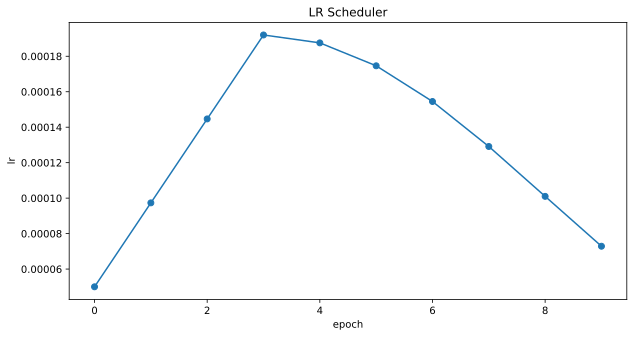

In [16]:
lr_cb = get_lr_callback(CFG.batch_size, mode=CFG.lr_mode, plot=True)

# 💾 | Model Checkpointing

In [17]:
# Create models directory if it doesn't exist
models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

model_checkpoint_path = str(models_dir / "best_model.keras")

ckpt_cb = keras.callbacks.ModelCheckpoint(model_checkpoint_path,
                                         monitor='val_loss',
                                         save_best_only=True,
                                         save_weights_only=False,
                                         mode='min')

print(f"Model will be saved to: {model_checkpoint_path}")

Model will be saved to: /home/littl/ECE247A_Final_Project/baselines/models/best_model.keras


# 🚂 | Training

In [18]:
# history = model.fit(
#     train_ds, 
#     epochs=CFG.epochs,
#     callbacks=[lr_cb, ckpt_cb], 
#     steps_per_epoch=len(train_df)//CFG.batch_size,
#     validation_data=valid_ds, 
#     verbose=CFG.verbose
# )


# import matplotlib.pyplot as plt

# # Print table
# print(f"{'Epoch':<10} {'Train Loss':<15} {'Val Loss':<15}")
# print("-" * 40)
# for epoch, (train, val) in enumerate(zip(
#     history.history['loss'], 
#     history.history['val_loss']), 1):
#     print(f"{epoch:<10} {train:<15.6f} {val:<15.6f}")

# # Plot
# plt.figure(figsize=(10, 4))
# plt.plot(history.history['loss'], label='Train Loss')
# plt.plot(history.history['val_loss'], label='Val Loss')
# plt.xlabel('Epoch')
# plt.ylabel('KL Divergence Loss')
# plt.title('Training vs Validation Loss')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# 🧪 | Test Evaluation

## Load Best Model

In [19]:
import gc
gc.collect()
tf.keras.backend.clear_session()

# Reload model fresh
model = keras_cv.models.ImageClassifier.from_preset(
    CFG.preset, num_classes=CFG.num_classes
)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss=LOSS)
model.load_weights(model_checkpoint_path)

model.load_weights(model_checkpoint_path)
print(f"Model weights loaded from: {model_checkpoint_path}")

/opt/conda/envs/starternb/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:394: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 626 variables. 
  trackable.load_own_variables(weights_store.get(inner_path))


Model weights loaded from: /home/littl/ECE247A_Final_Project/baselines/models/best_model.keras


## Build Test Dataset

In [20]:
# Build test dataset fresh
test_paths = test_df.spec2_path.values
test_offsets = test_df.spectrogram_label_offset_seconds.values.astype(int)
test_labels = test_df.class_label.values

# Dataset without labels for prediction
test_ds = build_dataset(test_paths, test_offsets, batch_size=4,
                        repeat=False, shuffle=False, cache=False, augment=False)

# Dataset with labels for loss evaluation
test_ds_labeled = build_dataset(test_paths, test_offsets, test_labels, batch_size=4,
                                repeat=False, shuffle=False, cache=False, augment=False)

# Verify shape
for x in test_ds.take(1):
    print("test_ds shape:", x.shape)  # Should be (8, 400, 300, 3)


test_ds shape: (4, 400, 300, 3)


2026-03-11 04:40:05.311138: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Inference

In [21]:
import gc
import tensorflow as tf
import keras

# Force full GPU memory release
tf.keras.backend.clear_session()
gc.collect()

# Limit GPU memory growth to avoid OO

# Reload best saved model fresh
model = keras.models.load_model(model_checkpoint_path)

# Rebuild test_ds fresh
test_ds = build_dataset(test_paths, test_offsets, batch_size=3,  # smaller batch
                        repeat=False, shuffle=False, cache=False, augment=False, drop_remainder=True)

preds = model.predict(test_ds)
print("Predictions shape:", preds.shape)

/opt/conda/envs/starternb/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:394: UserWarning: Skipping variable loading for optimizer 'adam', because it has 622 variables whereas the saved optimizer has 626 variables. 
  trackable.load_own_variables(weights_store.get(inner_path))
I0000 00:00:1773204018.572388  612581 service.cc:145] XLA service 0x7fa5a80023e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773204018.572437  612581 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-03-11 04:40:18.754821: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-11 04:40:19.666516: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


   9/2207 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step

I0000 00:00:1773204023.941696  612581 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2207/2207 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step
Predictions shape: (6621, 6)


## Test Loss

Evaluate the KL Divergence loss on the test set using the best model.

In [22]:
# Evaluate test loss
test_loss = model.evaluate(test_ds_labeled, verbose=CFG.verbose)
print(f"\nTest KL Divergence Loss: {test_loss:.6f}")

1656/1656 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - loss: 0.7764

Test KL Divergence Loss: 0.833495


# 📩 | Submission

In [23]:
# Create output directory for submission
output_dir = project_root / "results"
output_dir.mkdir(parents=True, exist_ok=True)

pred_df = test_df[["eeg_id"]].copy()
target_cols = [x.lower()+'_vote' for x in CFG.class_names]

# Align lengths
pred_df = pred_df.iloc[:len(preds)].reset_index(drop=True)
pred_df[target_cols] = preds.tolist()

print(f"test_df: {len(test_df)} | preds: {len(preds)} | submission: {len(pred_df)}")

# Save submission
submission_path = str(output_dir / "submission_baseline.csv")
pred_df.to_csv(submission_path, index=False)
print(f"Submission saved to: {submission_path}")

print("\nSubmission preview:")
print(pred_df.head())

test_df: 6621 | preds: 6621 | submission: 6621
Submission saved to: /home/littl/ECE247A_Final_Project/baselines/results/submission_baseline.csv

Submission preview:
       eeg_id  seizure_vote  lpd_vote  gpd_vote  lrda_vote  grda_vote  \
0  4245882082      0.547208  0.016103  0.004594   0.044609   0.106539   
1  2857590162      0.153798  0.059916  0.226647   0.063550   0.117868   
2  2857590162      0.115364  0.047037  0.200767   0.055804   0.132881   
3  2857590162      0.104312  0.043748  0.105967   0.055348   0.140475   
4  3523834378      0.795834  0.005837  0.021986   0.017180   0.032213   

   other_vote  
0    0.280946  
1    0.378222  
2    0.448147  
3    0.550150  
4    0.126951  
